In [1]:
import sys
print(sys.executable)
print(sys.version)

e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Scripts\python.exe
3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import sklearn
import tensorflow as tf

print("All libraries imported successfully")
print("TensorFlow version:", tf.__version__)


All libraries imported successfully
TensorFlow version: 2.15.0


In [3]:
import pandas as pd

file_path = "../data/processed/arxiv_15000_balanced.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (15000, 5)


,title,abstract,categories,main_category,text
0,Spin glass models for a network of real neurons,Ising models with pairwise interactions are th...,q-bio.NC,Quantitative Biology,Spin glass models for a network of real neuron...
1,Relative-Error CUR Matrix Decompositions,Many data analysis applications deal with larg...,cs.DS,Computer Science,Relative-Error CUR Matrix Decompositions Many ...
2,Large-scale interval and point estimates from ...,The proposed approach extends the confidence p...,stat.ME math.ST q-bio.QM stat.AP stat.TH,Statistics,Large-scale interval and point estimates from ...
3,A binary model for the UV-upturn of elliptical...,The discovery of a flux excess in the far-ultr...,astro-ph,Physics,A binary model for the UV-upturn of elliptical...
4,Building Decision Procedures in the Calculus o...,It is commonly agreed that the success of futu...,cs.LO,Computer Science,Building Decision Procedures in the Calculus o...


In [4]:
print(df.columns)

Index(['title', 'abstract', 'categories', 'main_category', 'text'], dtype='str')


In [5]:
df.isnull().sum()

title            0
abstract         0
categories       0
main_category    0
text             0
dtype: int64

In [6]:
df["main_category"].value_counts()

main_category
Quantitative Biology    2500
Computer Science        2500
Statistics              2500
Physics                 2500
Mathematics             2500
Quantitative Finance    2500
Name: count, dtype: int64

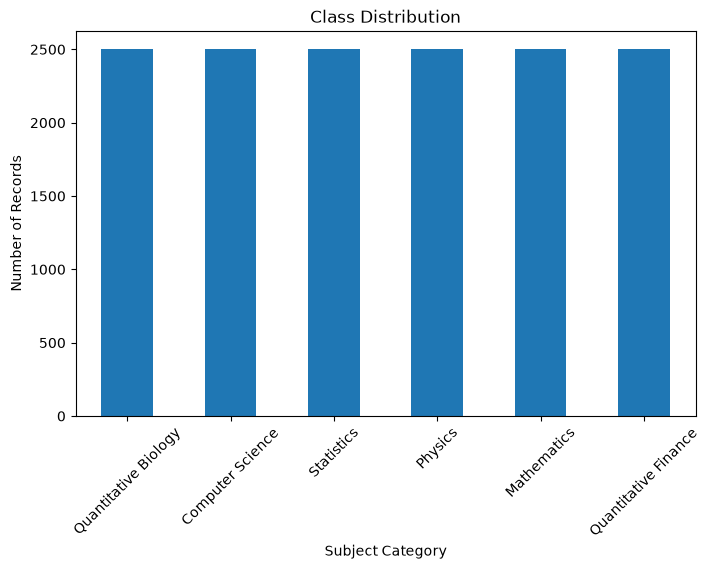

In [7]:
import matplotlib.pyplot as plt

df["main_category"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Class Distribution")
plt.xlabel("Subject Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [8]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "main_category"]].head()

,text,clean_text,main_category
0,Spin glass models for a network of real neuron...,spin glass models for a network of real neuron...,Quantitative Biology
1,Relative-Error CUR Matrix Decompositions Many ...,relative error cur matrix decompositions many ...,Computer Science
2,Large-scale interval and point estimates from ...,large scale interval and point estimates from ...,Statistics
3,A binary model for the UV-upturn of elliptical...,a binary model for the uv upturn of elliptical...,Physics
4,Building Decision Procedures in the Calculus o...,building decision procedures in the calculus o...,Computer Science


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["main_category"])

print(label_encoder.classes_)
df[["main_category", "label"]].head()

['Computer Science' 'Mathematics' 'Physics' 'Quantitative Biology'
 'Quantitative Finance' 'Statistics']


,main_category,label
0,Quantitative Biology,3
1,Computer Science,0
2,Statistics,5
3,Physics,2
4,Computer Science,0


In [10]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (12000,)
Test size: (3000,)


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_
))

Logistic Regression Accuracy: 0.8933333333333333
                      precision    recall  f1-score   support

    Computer Science       0.87      0.86      0.86       500
         Mathematics       0.87      0.92      0.89       500
             Physics       0.93      0.88      0.90       500
Quantitative Biology       0.88      0.90      0.89       500
Quantitative Finance       0.97      0.94      0.95       500
          Statistics       0.85      0.87      0.86       500

            accuracy                           0.89      3000
           macro avg       0.89      0.89      0.89      3000
        weighted avg       0.89      0.89      0.89      3000



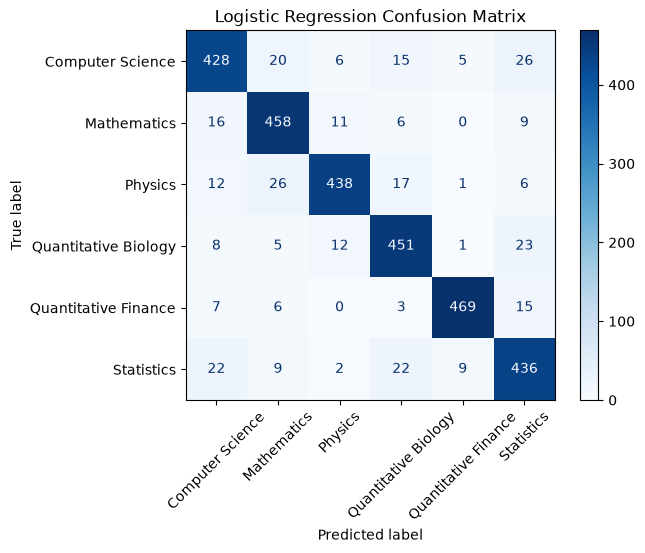

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [13]:
import joblib

joblib.dump(log_reg, "../models/member1_logistic_regression.pkl")
joblib.dump(tfidf, "../models/member1_tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../models/member1_label_encoder.pkl")

print("Logistic Regression model, TF-IDF vectorizer, and label encoder saved successfully.")

Logistic Regression model, TF-IDF vectorizer, and label encoder saved successfully.


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["main_category"])

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

NameError: name 'df' is not defined

In [7]:
import pandas as pd
import re

# Load dataset again
file_path = "../data/processed/arxiv_15000_balanced.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)
print(df.columns)

# If text column already exists, use it
# If not, create text column using title + abstract
if "text" not in df.columns:
    df["text"] = df["title"].astype(str) + " " + df["abstract"].astype(str)

# Clean text function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Create clean_text column
df["clean_text"] = df["text"].apply(clean_text)

print("Text cleaning completed")
df[["text", "clean_text", "main_category"]].head()

Dataset loaded successfully
Dataset shape: (15000, 5)
Index(['title', 'abstract', 'categories', 'main_category', 'text'], dtype='str')
Text cleaning completed


,text,clean_text,main_category
0,Spin glass models for a network of real neuron...,spin glass models for a network of real neuron...,Quantitative Biology
1,Relative-Error CUR Matrix Decompositions Many ...,relative error cur matrix decompositions many ...,Computer Science
2,Large-scale interval and point estimates from ...,large scale interval and point estimates from ...,Statistics
3,A binary model for the UV-upturn of elliptical...,a binary model for the uv upturn of elliptical...,Physics
4,Building Decision Procedures in the Calculus o...,building decision procedures in the calculus o...,Computer Science


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["main_category"])

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (12000,)
Test size: (3000,)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_
))

Logistic Regression Accuracy: 0.8933333333333333
                      precision    recall  f1-score   support

    Computer Science       0.87      0.86      0.86       500
         Mathematics       0.87      0.92      0.89       500
             Physics       0.93      0.88      0.90       500
Quantitative Biology       0.88      0.90      0.89       500
Quantitative Finance       0.97      0.94      0.95       500
          Statistics       0.85      0.87      0.86       500

            accuracy                           0.89      3000
           macro avg       0.89      0.89      0.89      3000
        weighted avg       0.89      0.89      0.89      3000



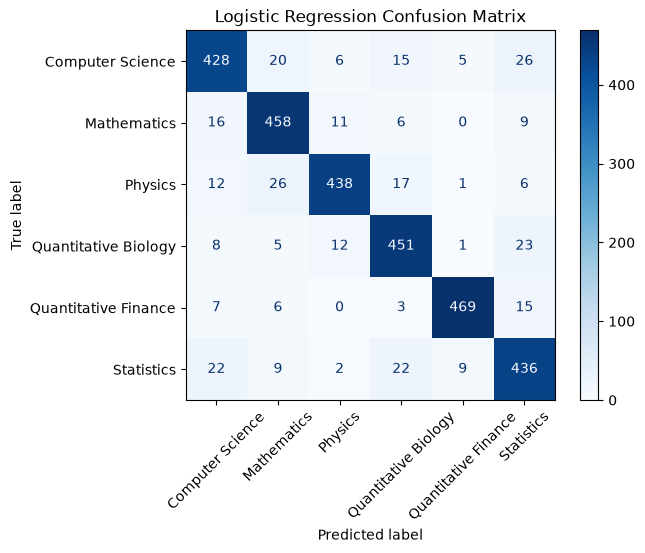

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [11]:
import joblib

joblib.dump(log_reg, "../models/member1_logistic_regression.pkl")
joblib.dump(tfidf, "../models/member1_tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../models/member1_label_encoder.pkl")

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


<Figure size 1000x800 with 0 Axes>

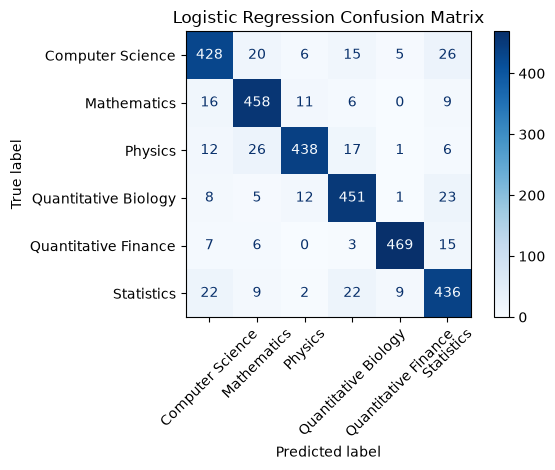

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

plt.savefig("../screenshots/member1_logistic_regression_confusion_matrix.png", dpi=300)

plt.show()

In [13]:
import joblib

joblib.dump(log_reg, "../models/member1_logistic_regression.pkl")
joblib.dump(tfidf, "../models/member1_tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../models/member1_label_encoder.pkl")

print("Logistic Regression model, TF-IDF vectorizer, and label encoder saved successfully.")

Logistic Regression model, TF-IDF vectorizer, and label encoder saved successfully.


In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000
max_len = 250

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("Train shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)


Train shape: (12000, 250)
Test shape: (3000, 250)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

num_classes = len(label_encoder.classes_)

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 250, 128)          2560000   
                                                                 
 lstm (LSTM)                 (None, 128)               131584    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 6)                 390       
                                                                 
Total params: 2700230 (10.30 MB)
Trainable params: 270

In [16]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=64
)

Epoch 1/3


150/150 [==============================] - 36s 226ms/step - loss: 1.7913 - accuracy: 0.1708 - val_loss: 1.7846 - val_accuracy: 0.1796
Epoch 2/3
150/150 [==============================] - 41s 273ms/step - loss: 1.7809 - accuracy: 0.1878 - val_loss: 1.7837 - val_accuracy: 0.1892
Epoch 3/3
150/150 [==============================] - 46s 304ms/step - loss: 1.7688 - accuracy: 0.1910 - val_loss: 1.7735 - val_accuracy: 0.1779


In [17]:
loss, accuracy_lstm = lstm_model.evaluate(X_test_pad, y_test)

print("LSTM Test Loss:", loss)
print("LSTM Test Accuracy:", accuracy_lstm)

94/94 [==============================] - 2s 24ms/step - loss: 1.7825 - accuracy: 0.1723
LSTM Test Loss: 1.7824910879135132
LSTM Test Accuracy: 0.17233332991600037


In [18]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)

print(classification_report(
    y_test,
    y_pred_lstm,
    target_names=label_encoder.classes_
))

94/94 [==============================] - 3s 24ms/step
                      precision    recall  f1-score   support

    Computer Science       0.00      0.00      0.00       500
         Mathematics       0.00      0.00      0.00       500
             Physics       0.28      0.01      0.02       500
Quantitative Biology       0.30      0.06      0.11       500
Quantitative Finance       0.00      0.00      0.00       500
          Statistics       0.17      0.96      0.28       500

            accuracy                           0.17      3000
           macro avg       0.12      0.17      0.07      3000
        weighted avg       0.12      0.17      0.07      3000



e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "LSTM"],
    "Accuracy": [accuracy_lr, accuracy_lstm]
})

results

,Model,Accuracy
0,Logistic Regression,0.893333
1,LSTM,0.172333


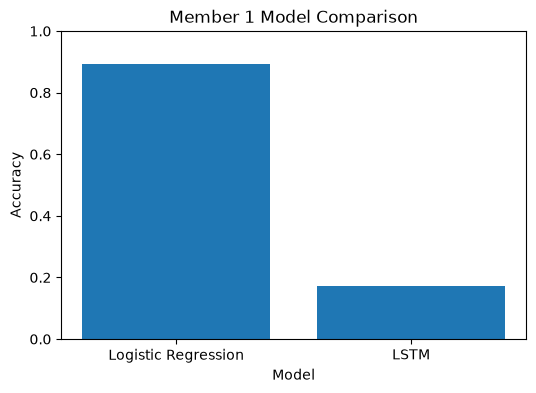

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Member 1 Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [21]:
import joblib

lstm_model.save("../models/member1_lstm_model.h5")
joblib.dump(tokenizer, "../models/member1_lstm_tokenizer.pkl")

print("LSTM model and tokenizer saved successfully.")

e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


LSTM model and tokenizer saved successfully.


In [1]:
import sys
import tensorflow as tf

print(sys.executable)
print(sys.version)
print("TensorFlow version:", tf.__version__)


e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Scripts\python.exe
3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]
TensorFlow version: 2.15.0


In [2]:
import pandas as pd
import re

file_path = "../data/processed/arxiv_15000_balanced.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully
Dataset shape: (15000, 5)


,title,abstract,categories,main_category,text
0,Spin glass models for a network of real neurons,Ising models with pairwise interactions are th...,q-bio.NC,Quantitative Biology,Spin glass models for a network of real neuron...
1,Relative-Error CUR Matrix Decompositions,Many data analysis applications deal with larg...,cs.DS,Computer Science,Relative-Error CUR Matrix Decompositions Many ...
2,Large-scale interval and point estimates from ...,The proposed approach extends the confidence p...,stat.ME math.ST q-bio.QM stat.AP stat.TH,Statistics,Large-scale interval and point estimates from ...
3,A binary model for the UV-upturn of elliptical...,The discovery of a flux excess in the far-ultr...,astro-ph,Physics,A binary model for the UV-upturn of elliptical...
4,Building Decision Procedures in the Calculus o...,It is commonly agreed that the success of futu...,cs.LO,Computer Science,Building Decision Procedures in the Calculus o...


In [3]:
print(df.columns)
df.isnull().sum()

Index(['title', 'abstract', 'categories', 'main_category', 'text'], dtype='str')


title            0
abstract         0
categories       0
main_category    0
text             0
dtype: int64

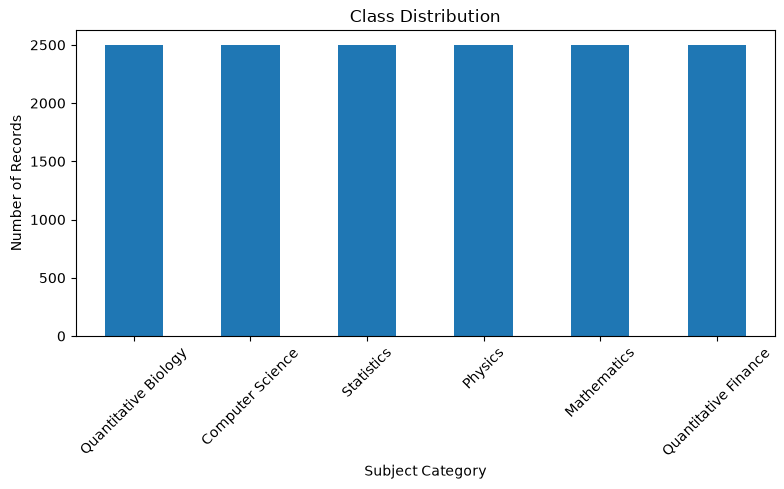

In [4]:
import matplotlib.pyplot as plt

df["main_category"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Class Distribution")
plt.xlabel("Subject Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "main_category"]].head()

,text,clean_text,main_category
0,Spin glass models for a network of real neuron...,spin glass models for a network of real neuron...,Quantitative Biology
1,Relative-Error CUR Matrix Decompositions Many ...,relative error cur matrix decompositions many ...,Computer Science
2,Large-scale interval and point estimates from ...,large scale interval and point estimates from ...,Statistics
3,A binary model for the UV-upturn of elliptical...,a binary model for the uv upturn of elliptical...,Physics
4,Building Decision Procedures in the Calculus o...,building decision procedures in the calculus o...,Computer Science


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["main_category"])

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print(label_encoder.classes_)

Train size: (12000,)
Test size: (3000,)
['Computer Science' 'Mathematics' 'Physics' 'Quantitative Biology'
 'Quantitative Finance' 'Statistics']


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_
))

Logistic Regression Accuracy: 0.8933333333333333
                      precision    recall  f1-score   support

    Computer Science       0.87      0.86      0.86       500
         Mathematics       0.87      0.92      0.89       500
             Physics       0.93      0.88      0.90       500
Quantitative Biology       0.88      0.90      0.89       500
Quantitative Finance       0.97      0.94      0.95       500
          Statistics       0.85      0.87      0.86       500

            accuracy                           0.89      3000
           macro avg       0.89      0.89      0.89      3000
        weighted avg       0.89      0.89      0.89      3000



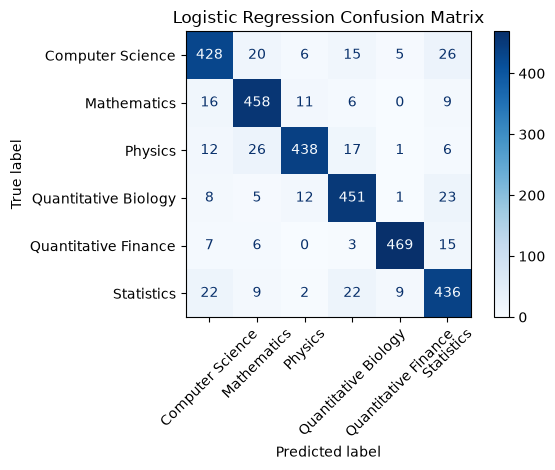

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000
max_len = 250

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("Train shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)

Train shape: (12000, 250)
Test shape: (3000, 250)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

num_classes = len(label_encoder.classes_)

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 250, 128)          2560000   
                                                                 
 lstm (LSTM)                 (None, 128)               131584    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 6)                 390       
                                                                 
Total params: 2700230 (10.30 MB)
Trainable params: 270

In [11]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=64
)

Epoch 1/3


150/150 [==============================] - 20s 123ms/step - loss: 1.7902 - accuracy: 0.1757 - val_loss: 1.7855 - val_accuracy: 0.1858
Epoch 2/3
150/150 [==============================] - 19s 123ms/step - loss: 1.7668 - accuracy: 0.1983 - val_loss: 1.7337 - val_accuracy: 0.2075
Epoch 3/3
150/150 [==============================] - 19s 124ms/step - loss: 1.7400 - accuracy: 0.2179 - val_loss: 1.6490 - val_accuracy: 0.2392


In [12]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=64
)

Epoch 1/3
150/150 [==============================] - 21s 139ms/step - loss: 1.7721 - accuracy: 0.1926 - val_loss: 1.7909 - val_accuracy: 0.1742
Epoch 2/3
150/150 [==============================] - 20s 130ms/step - loss: 1.7771 - accuracy: 0.1886 - val_loss: 1.7741 - val_accuracy: 0.1754
Epoch 3/3
150/150 [==============================] - 19s 127ms/step - loss: 1.7582 - accuracy: 0.1926 - val_loss: 1.7813 - val_accuracy: 0.1796


In [13]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)

print(classification_report(
    y_test,
    y_pred_lstm,
    target_names=label_encoder.classes_
))

94/94 [==============================] - 3s 24ms/step
                      precision    recall  f1-score   support

    Computer Science       0.25      0.00      0.00       500
         Mathematics       0.18      0.98      0.30       500
             Physics       1.00      0.01      0.02       500
Quantitative Biology       0.31      0.04      0.08       500
Quantitative Finance       0.00      0.00      0.00       500
          Statistics       0.25      0.07      0.11       500

            accuracy                           0.18      3000
           macro avg       0.33      0.18      0.09      3000
        weighted avg       0.33      0.18      0.09      3000



e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [15]:
loss, accuracy_lstm = lstm_model.evaluate(X_test_pad, y_test)

print("LSTM Test Loss:", loss)
print("LSTM Test Accuracy:", accuracy_lstm)

94/94 [==============================] - 2s 24ms/step - loss: 1.7833 - accuracy: 0.1847
LSTM Test Loss: 1.7832568883895874
LSTM Test Accuracy: 0.18466666340827942


In [16]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "LSTM"],
    "Accuracy": [accuracy_lr, accuracy_lstm]
})

results

,Model,Accuracy
0,Logistic Regression,0.893333
1,LSTM,0.184667


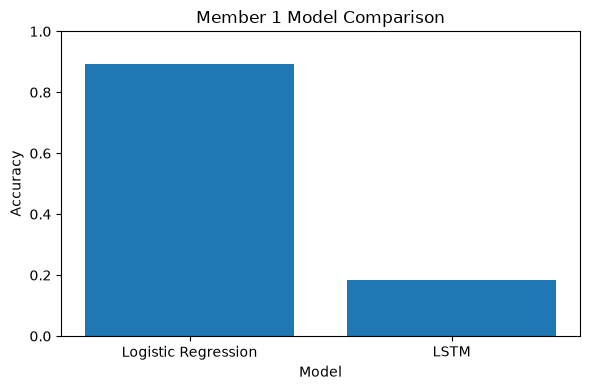

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Member 1 Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(log_reg, "../models/member1_logistic_regression.pkl")
joblib.dump(tfidf, "../models/member1_tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../models/member1_label_encoder.pkl")

lstm_model.save("../models/member1_lstm_model.h5")
joblib.dump(tokenizer, "../models/member1_lstm_tokenizer.pkl")

print("All Member 1 models saved successfully.")

e:\NLP_Group_20_ROT-NLP-Solutions_\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


All Member 1 models saved successfully.


In [19]:
import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)